# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

_Fill in your group number **from Brightspace**, names, and student numbers._

|  Group 35  |           Student number          |
|------------|----------------------|
| Belouaer, Zeyd  |        6160662       |,
| Dos Santos Roldão, Vasco  |        6127916       |
| Jacobs, Mats  |        6255698       |
| Kopmels, Kylian  |        6164846       |

#### Imports

In [26]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
import random
from typing import Dict, List
from tqdm import tqdm

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action
np.random.seed(42)
random.seed(42)

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [27]:
class ExplorationStrategy:
    def __init__(self, q_table: QTable):
        self.q_table = q_table

    def execute(self,agent,maze,action):
        return agent.step(action, maze), action
    
    def random(self, agent: Agent, maze: Maze):
        """
        The random exploration strategy selects a random action uniformly at random
        from the set of all valid actions.
        """
        return self.execute(agent, maze,self.get_random_action(agent, maze))
    
    def get_random_action(self, agent: Agent, maze: Maze):
        actions = agent.get_valid_actions(maze)
        action = actions[np.random.randint(len(actions))]
        return action


    def e_greedy(self, agent: Agent, maze: Maze, eps: float):
        """
        The e-greedy exploration strategy selects a random action with probability eps,
        and the action with highest q-value with probability 1 - eps. A value of epsilon
        close to 0 favours exploitation, while a value close to 1 favours exploration.
        """

        return self.execute(agent, maze, self.get_greedy(agent, maze, eps))

    def get_greedy(self, agent: Agent, maze: Maze, eps: float):
            actions = agent.get_valid_actions(maze)
            if np.random.rand() < eps:
                return self.get_random_action(agent, maze)
            else:
                scores = [self.q_table.get_q(agent.get_state(maze), a) for a in actions]
                mm0 = np.max(scores)
                candidates = [i for i, v in enumerate(scores) if v == mm0]
                action = actions[random.choice(candidates)]
                return action
            
    def boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        """
        The Boltzmann exploration strategy assigns a probability to each action based on its estimated q-values.
        A large value of the temperature encourages exploration, and as the temperature declines over time,
        exploitation is favoured. 
        """

        return self.execute(agent, maze, self.get_boltzmann(agent, maze, temperature))

    def get_boltzmann(self, agent: Agent, maze: Maze, temperature: float):
        actions = agent.get_valid_actions(maze)
        scores = np.array([self.q_table.get_q(agent.get_state(maze), a) / temperature for a in actions])
        scores_stable = scores - np.max(scores)
        output = np.exp(scores_stable) 
        output /= np.sum(output)
        action = np.random.choice(actions, p = output)
        return action

Random has no hyperparameters nor an interesting implementation, we just pick a random action and take it.

E-greedy calls random with a probablity of the hyperparameter epsilon, for which we choose $0.1$ as this seems like it would allow for enough exploration to find a good path while also making sure that our solutions don't get worse on average as we still pick our current best path with $0.9$ probability.

Boltzmann takes a path with the probability proportional to its Q-score, similarly to roulette wheel in genetic algorithms. We can tune the temperature to encourage exploration (for high temperatures) or exploitation (low temperatures). We will pick $T = 1.5$ to encourage exploration in order to help prevent local minima, while still reasonably converging to a good solution.

For sufficient exploration we can use either ε-greedy or boltzmann. Random does not have any exploitation and will thus not converge to a good solution, ε-greedy/boltzmann with $ε = 0.1$ and $T = 1.5$ respectively have sufficient exploration and exploitation to find paths towards the goal.

#### Question 2

100%|██████████| 300/300 [00:08<00:00, 34.08it/s]


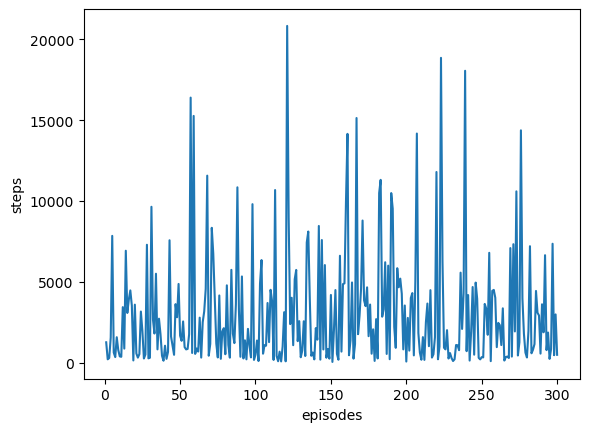

In [28]:
# Create a Maze instance.
maze = Maze("./../data/easy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)
n_episodes = 300

def main(maze):
    # Create an Agent.
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": 0.7, "gamma": 0.9}
    # learner = QLearning(q_table, params)

    # Hyper-parameters.
    episode_lengths = []
    episode_rewards = []
    steps = np.zeros(n_episodes)

    for episode in tqdm(range(n_episodes)):
        done = False
        agent.reset()
        while not done:
            state = agent.get_state(maze)
            (next, reward, done), action = exploration_strategy.e_greedy(agent, maze, 0.1)
            valid_actions = agent.get_valid_actions(maze)
            steps[episode] += 1
            # learner.learn(valid_actions, state, action, next, reward, done)
    return steps

steps = main(maze)
plt.xlabel("episodes")
plt.ylabel("steps")
linspace = np.linspace(1,n_episodes, n_episodes)
plt.plot(linspace,steps)

We get the current state, and the valid actions from that current state, take an e-greedy step (boltzmann would also be possible, both step functions are okay), and we conceptually pass it to the learning method that we will implement later so that we can update the q-table. 

We see that the amount of steps needed to get to the ending is pretty much completely random.

#### Question 3

In [29]:
# Hyper-parameters.

def main_limited(maze):
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": 0.7, "gamma": 0.9}
    # learner = QLearning(q_table, params)

    # Hyper-parameters.
    n_episodes = 300
    episode_lengths = []
    episode_rewards = []
    steps = np.zeros(n_episodes)
    totalsteps = 0
    episodes = 0
    for episode in tqdm(range(n_episodes)):
        if totalsteps >= 30000:
            break
        done = False
        agent.reset()

        while not done and totalsteps < 30000:
            state = agent.get_state(maze)
            (next, reward, done), action = exploration_strategy.e_greedy(agent, maze, 0.1)
            valid_actions = agent.get_valid_actions(maze)
            steps[episode] += 1
            totalsteps += 1
            if(totalsteps >= 30000):
                steps[episode] = 0
            # learner.learn(valid_actions, state, action, next, reward, done)
        episodes += 1
    return steps, episodes, totalsteps
            
steps2, eps, totalsteps = main_limited(maze)
print(totalsteps)

  2%|▏         | 6/300 [00:00<00:14, 19.83it/s]

30000


We count the total steps taken every time we iterate over the loop where a step has been taken. After 30000 steps have been taken, we exit out of both the inner and the outer loop. We print the number of total steps and see that indeed we did 30000 steps. We keep track of the amount of episodes, so we can have an easier time plotting.

#### Question 4

  3%|▎         | 9/300 [00:00<00:09, 30.68it/s]


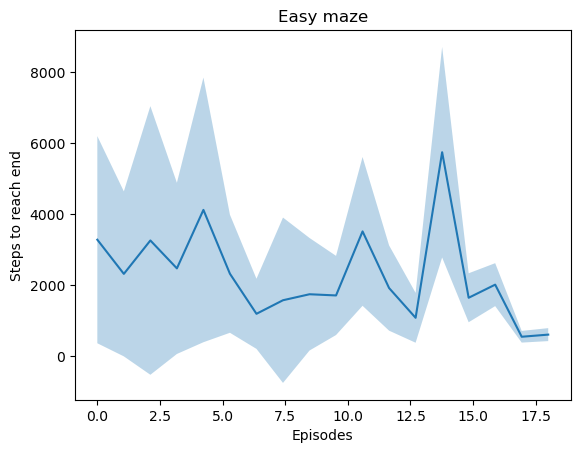

  6%|▌         | 18/300 [00:00<00:04, 62.33it/s]


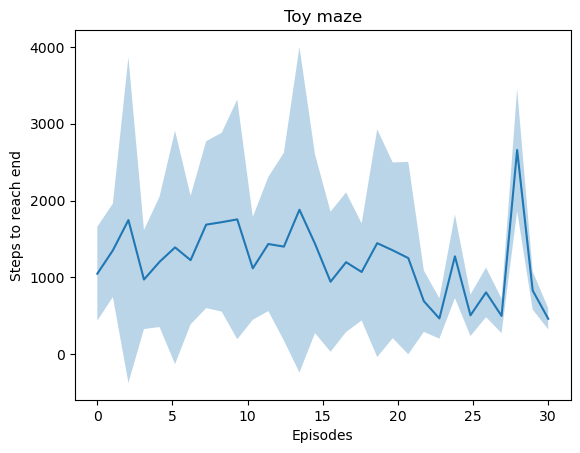

In [ ]:
all_runs = []
for i in range(10):
    to_add, eps, _ = main_limited(maze) 
    all_runs.append(to_add)

all_runs = np.array(all_runs)
divisors = np.sum(all_runs != 0, axis=0).astype(float)
divisors[divisors == 0.0] = 1.0 #prevent dividing by 0

out_easy = np.sum(all_runs, axis=0) / divisors
std = np.std(all_runs, axis=0)[out_easy != 0.0]
out_easy = out_easy[out_easy != 0.0]

plt.xlabel("Episodes")
plt.ylabel("Steps to reach end")
plt.title("Easy maze")
plt.plot(np.linspace(0, len(out_easy), len(out_easy)), out_easy)
plt.fill_between(np.linspace(0, len(out_easy), len(out_easy)), out_easy - std, out_easy + std, alpha=0.3, label="Standard deviation")
plt.show()

toy_maze = Maze("./../data/toy_maze.txt")
toy_maze.set_reward(x=9, y=9, reward=10)
toy_maze.set_terminal(x=9, y=9)

all_runs = []
for i in range(10):
    to_add, eps,_ = main_limited(toy_maze) 
    all_runs.append(to_add)

all_runs = np.array(all_runs)
divisors = np.sum(all_runs != 0, axis=0).astype(float)
divisors[divisors == 0.0] = 1.0 #prevent dividing by 0

out_easy = np.sum(all_runs, axis=0) / divisors
std = np.std(all_runs, axis=0)[out_easy != 0.0]
out_easy = out_easy[out_easy != 0.0]

plt.xlabel("Episodes")
plt.ylabel("Steps to reach end")
plt.title("Toy maze")
plt.plot(np.linspace(0,len(out_easy),len(out_easy)),out_easy)
plt.fill_between(np.linspace(0,len(out_easy),len(out_easy)), out_easy - std, out_easy + std, alpha=0.3, label="Standard deviation")
plt.show()


For both mazes, what we did is:

Run the algorithm on it 10 times, then take the average over the algorithms that got a non-0 steps solution for it (as this only happens when we exceed 30k steps, making the algorithm not run). For cleanliness we then remove the 0-entries.

As clearly visible, the graphs for both mazes are seemingly completely random. There is no reason to believe there is any correlation. The massive uncertainty also shows this.

#### Question 5

In [31]:
class QLearning:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params

    def learn(self, possible_actions: List[Action], state: State, action: Action,
               next_state: State, reward: int, done: bool) -> None:
        
        qmax = 0 if done else np.max(np.array([self.q_table.get_q(next_state, a) for a in possible_actions]))
        current = self.q_table.get_q(state,action)
        value = current + self.params["lr"] * (reward + self.params["gamma"] * qmax - current)
        self.q_table.set_q(state,action, value)

In [32]:
class SARSA:

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        self.q_table = q_table
        self.params = params
    
    def learn(self, state: State, action: Action, next_state: State, next_action: Action,
               reward: float, done: bool) -> None:
        
        qmax = 0 if done else self.q_table.get_q(next_state,next_action)
        current = self.q_table.get_q(state,action)
        value = current + self.params["lr"] * (reward + self.params["gamma"] * qmax - current)
        self.q_table.set_q(state,action, value)

We implemented Q-learning, who'se formula updates the q-value of the current state and action by checking in which state it maps to and what the best known action is to take in that future state state.

We also implemented SARSA, who is only different becauze it checks what the actual next step taken is instead of the optimal one.

#### Question 6

  5%|▌         | 16/300 [00:00<00:07, 36.55it/s]


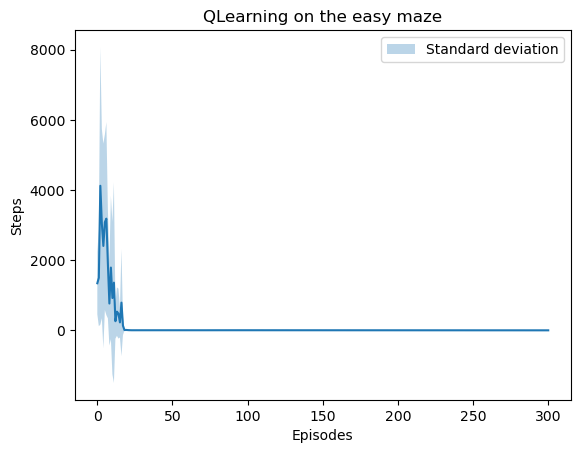

100%|██████████| 300/300 [00:00<00:00, 1233.18it/s]


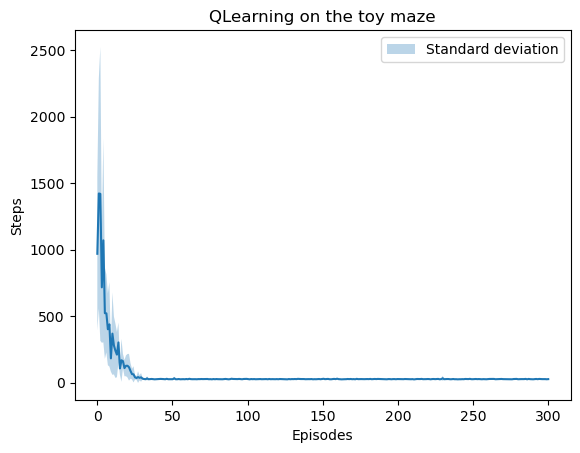

100%|██████████| 300/300 [00:00<00:00, 1109.95it/s]


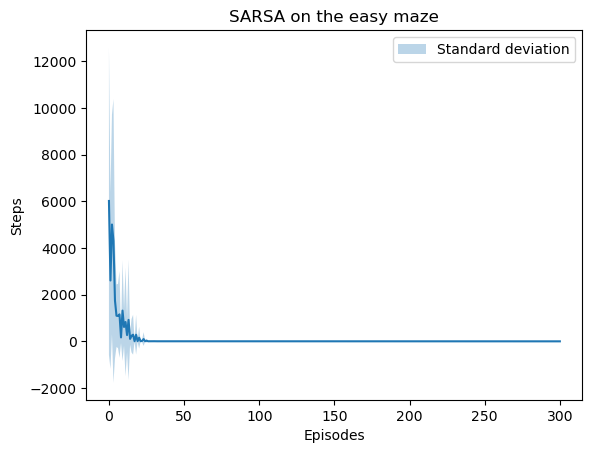

100%|██████████| 300/300 [00:00<00:00, 1758.81it/s]


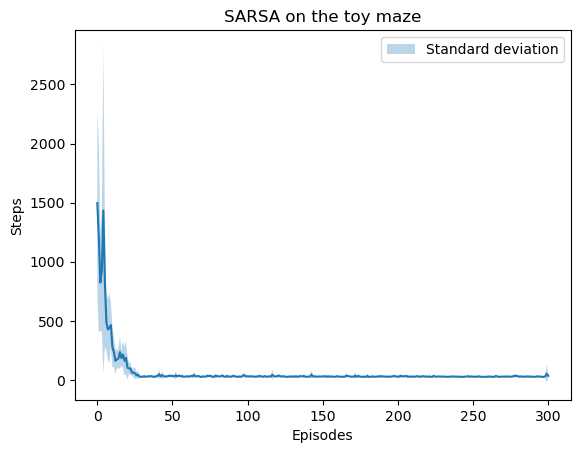

In [48]:
def main_with_qlearn(maze):
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": 0.7, "gamma": 0.9}
    learner = QLearning(q_table, params)

    # Hyper-parameters.
    n_episodes = 300
    episode_lengths = []
    episode_rewards = []
    steps = np.zeros(n_episodes)
    total_steps = 0
    episodes = 0
    
    for episode in tqdm(range(n_episodes)):
        if total_steps >= 30000:
            break
        done = False
        agent.reset()

        while not done and total_steps < 30000:
            state = agent.get_state(maze)
            (next, reward, done), action = exploration_strategy.e_greedy(agent, maze, 0.1)
            valid_actions = agent.get_valid_actions(maze)
            steps[episode] += 1
            total_steps += 1
            if(total_steps >= 30000):
                steps[episode] = 0
            learner.learn(valid_actions, state, action, next, reward, done)
        episodes += 1
    return steps, episodes, total_steps


def main_with_sarsa(maze):
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": 0.7, "gamma": 0.9}
    learner = SARSA(q_table, params)

    # Hyper-parameters.
    n_episodes = 300
    episode_lengths = []
    episode_rewards = []
    steps = np.zeros(n_episodes)
    total_steps = 0
    episodes = 0
    
    for episode in tqdm(range(n_episodes)):
        # if total_steps >= 30000:
        #    break
        done = False
        agent.reset()
        next_action = exploration_strategy.get_greedy(agent, maze, 0.1)
        
        while not done and total_steps < 30000:
            state = agent.get_state(maze)
            (next, reward, done), action = exploration_strategy.execute(agent, maze, next_action)
            next_action = exploration_strategy.get_greedy(agent,maze,0.1)
            steps[episode] += 1
            total_steps += 1
            if(total_steps >= 30000):
                steps[episode] = 0
            learner.learn(state, action, next, next_action, reward, done)
        episodes += 1
    return steps, episodes, total_steps

runs = []
for i in range(10):
    steps_easy_q, _, _ = main_with_qlearn(maze)
    runs.append(steps_easy_q)
runs = np.array(runs)
mean_q_easy, std = np.mean(runs, axis=0), np.std(runs, axis = 0)
plt.xlabel("Episodes")
plt.ylabel("Steps")
plt.title("QLearning on the easy maze")
plt.plot(np.linspace(0, n_episodes, n_episodes), mean_q_easy)
plt.fill_between(np.linspace(0, n_episodes, n_episodes), mean_q_easy - std, mean_q_easy + std, alpha = 0.3, label = "Standard deviation")
plt.legend()
plt.show()

runs = []
for i in range(10):
    steps_toy_q, _, _ = main_with_qlearn(toy_maze)
    runs.append(steps_toy_q)
runs = np.array(runs)
mean_q_toy, std = np.mean(runs, axis=0), np.std(runs, axis = 0)
plt.xlabel("Episodes")
plt.ylabel("Steps")
plt.title("QLearning on the toy maze")
plt.plot(np.linspace(0, n_episodes, n_episodes), mean_q_toy)
plt.fill_between(np.linspace(0, n_episodes, n_episodes), mean_q_toy - std, mean_q_toy + std, alpha = 0.3, label = "Standard deviation")
plt.legend()
plt.show()

runs = []
for i in range(10):
    steps_easy_sarsa, _, _ = main_with_sarsa(maze)
    runs.append(steps_easy_sarsa)
runs = np.array(runs)
mean_s_easy, std = np.mean(runs, axis=0), np.std(runs, axis = 0)
plt.xlabel("Episodes")
plt.ylabel("Steps")
plt.title("SARSA on the easy maze")
plt.plot(np.linspace(0, n_episodes, n_episodes), mean_s_easy)
plt.fill_between(np.linspace(0, n_episodes, n_episodes), mean_s_easy - std, mean_s_easy + std, alpha = 0.3, label = "Standard deviation")
plt.legend()
plt.show()

runs = []
for i in range(10):
    steps_toy_sarsa, _, _ = main_with_sarsa(toy_maze)
    runs.append(steps_toy_sarsa)
runs = np.array(runs)
mean_s_toy, std = np.mean(runs, axis=0), np.std(runs, axis = 0)
plt.xlabel("Episodes")
plt.ylabel("Steps")
plt.title("SARSA on the toy maze")
plt.plot(np.linspace(0, n_episodes, n_episodes), mean_s_toy)
plt.fill_between(np.linspace(0, n_episodes, n_episodes), mean_s_toy - std, mean_s_toy + std, alpha = 0.3, label = "Standard deviation")
plt.legend()
plt.show()

We see the famous elbow shape on all 4 plots, telling us that we converge to a solution on each of them. This also shows that the model is learning, as we clearly see the amount of steps go down with more episodes. It appears that 300 episodes is not fully needed for convergence as both learning algorithms converge before episode 50. Furthermore, we see that the standard deviation is extremely high at the beginning and then evaporates when we converge.

#### Question 7

The graphs of QLearn are much more smooth than those of SARSA (which has many small "bumps" even after convergence). This is expected as QLearn formula has a lower variance as it always depends on the best move from the future state (its formula contains Q(s′, a_max) which is the q-value of the best action in the next state s′) while SARSA uses the actual next move (its formula contains Q(s′, a′) where a′ is the next action taken in the next state s′ according to our policy) which has a 0.1 chance to be completely random.

### 2.2 Optimization
#### Question 8

In [46]:
def qLearnHP(maze, lr, gamma, epsln):
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": lr, "gamma": gamma}
    learner = QLearning(q_table, params)

    # Hyper-parameters.
    n_episodes = 300
    episode_lengths = []
    episode_rewards = []
    steps = np.zeros(n_episodes)
    total_steps = 0
    episodes = 0
    
    for episode in tqdm(range(n_episodes)):
        done = False
        agent.reset()

        while not done and total_steps < 30000:
            state = agent.get_state(maze)
            (next, reward, done), action = exploration_strategy.e_greedy(agent, maze, epsln)
            valid_actions = agent.get_valid_actions(maze)
            steps[episode] += 1
            total_steps += 1
            if(total_steps >= 30000):
                steps[episode] = 0
            learner.learn(valid_actions, state, action, next, reward, done)
        episodes += 1
    return steps, episodes, total_steps

100%|██████████| 300/300 [00:00<00:00, 703.61it/s]


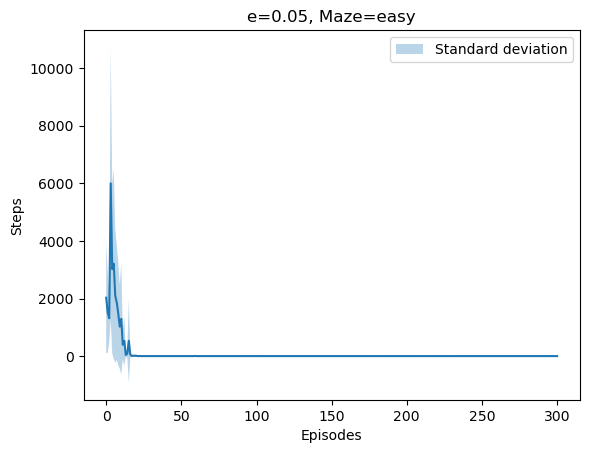

100%|██████████| 300/300 [00:00<00:00, 698.48it/s]


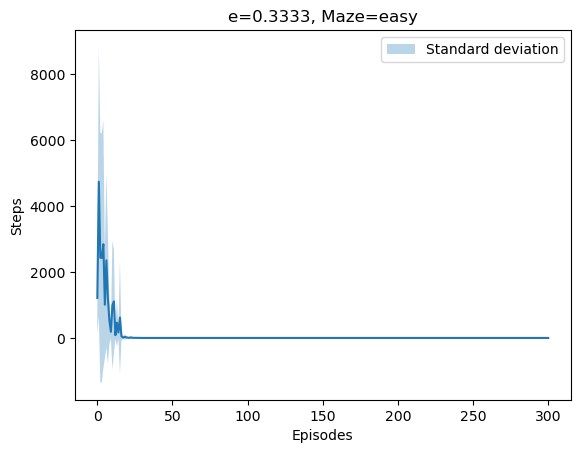

100%|██████████| 300/300 [00:00<00:00, 691.38it/s]


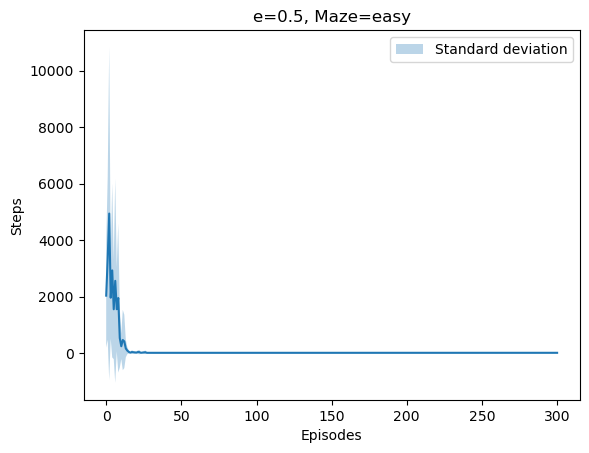

100%|██████████| 300/300 [00:00<00:00, 738.40it/s]


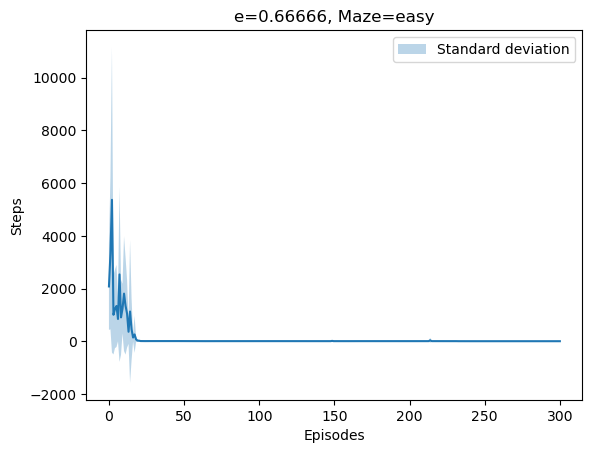

100%|██████████| 300/300 [00:00<00:00, 709.76it/s]


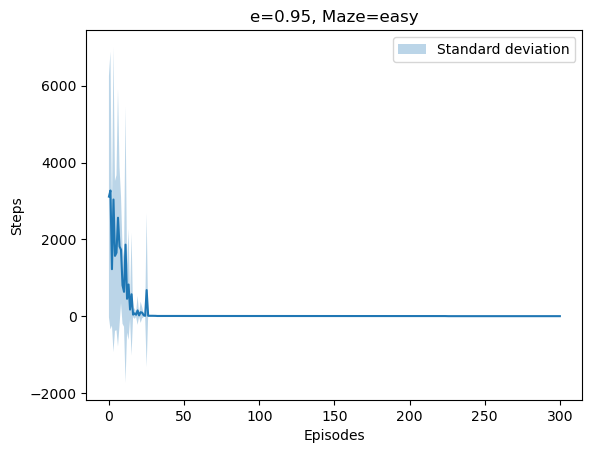

100%|██████████| 300/300 [00:00<00:00, 1088.80it/s]


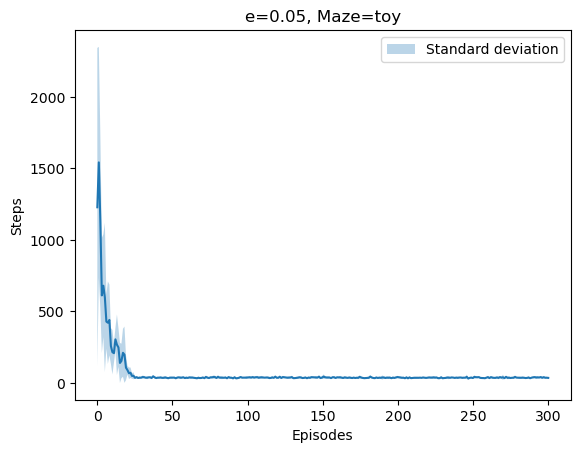

100%|██████████| 300/300 [00:00<00:00, 1077.67it/s]


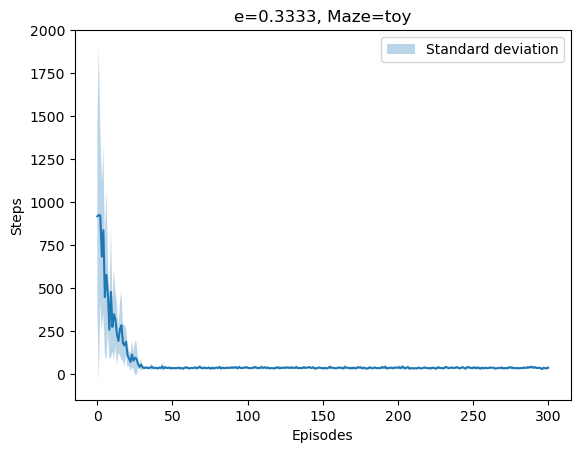

100%|██████████| 300/300 [00:00<00:00, 1068.36it/s]


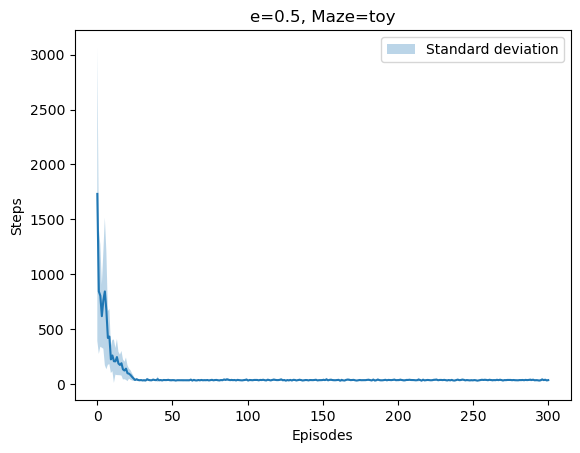

100%|██████████| 300/300 [00:00<00:00, 862.92it/s]


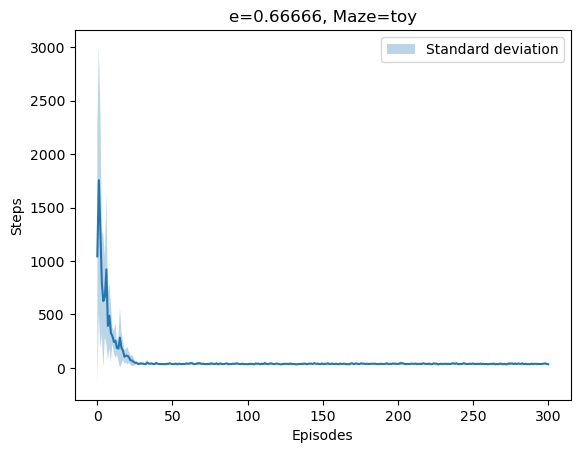

100%|██████████| 300/300 [00:00<00:00, 999.75it/s]


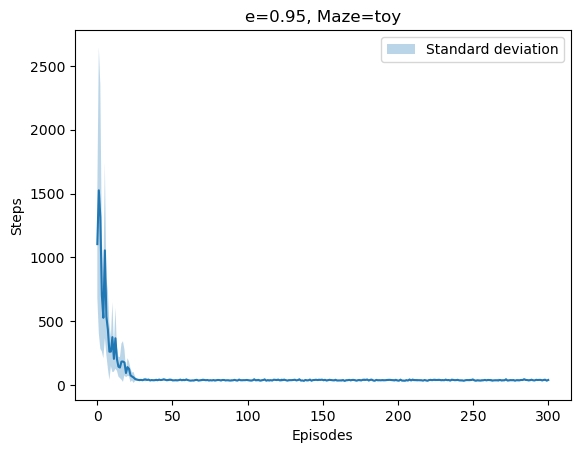

In [53]:
possMazes = ["easy", "toy"]

possibleVals = [0.05, 0.3333, 0.5, 0.66666, 0.95]

for i in range(len(possMazes)):
    mzString = "./../data/" + possMazes[i] + "_maze.txt"
    curMaze = Maze(file_path=mzString)
    curMaze.set_reward(x=9, y=9, reward=10)
    curMaze.set_terminal(x=9, y=9)
    for k in range(len(possibleVals)):
        runs0 = []
        for j in range(10):
            spc, _, _ = qLearnHP(curMaze, 0.7, 0.9, possibleVals[i])
            runs0.append(spc)
        avg, std = np.mean(runs0, axis=0), np.std(runs0, axis = 0)
        plt.xlabel("Episodes")
        plt.ylabel("Steps")
        plt.title("e=" + str(possibleVals[k]) + ", Maze=" + possMazes[i])
        plt.plot(np.linspace(0, n_episodes, n_episodes), avg)
        plt.fill_between(np.linspace(0, n_episodes, n_episodes), avg - std, avg + std, alpha = 0.3, label = "Standard deviation")
        plt.legend()
        plt.show()
        
        


We can see from the plots that for both mazes a bigger e generally results in a slightly faster convergence, while being more unstable than lower values, this makes sense since an agent with a high e favors exploration more than an agent with a low e.

#### Question 9

High values allow for faster convergence, however it also makes the agent unstable.

#### Question 10

In [54]:
def qLearnHPBolt(maze, lr, gamma, T):
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": lr, "gamma": gamma}
    learner = QLearning(q_table, params)

    # Hyper-parameters.
    n_episodes = 300
    episode_lengths = []
    episode_rewards = []
    steps = np.zeros(n_episodes)
    total_steps = 0
    episodes = 0
    
    for episode in tqdm(range(n_episodes)):
        done = False
        agent.reset()

        while not done and total_steps < 30000:
            state = agent.get_state(maze)
            (next, reward, done), action = exploration_strategy.boltzmann(agent, maze, T)
            valid_actions = agent.get_valid_actions(maze)
            steps[episode] += 1
            total_steps += 1
            if(total_steps >= 30000):
                steps[episode] = 0
            learner.learn(valid_actions, state, action, next, reward, done)
        episodes += 1
    return steps, episodes, total_steps

100%|██████████| 300/300 [00:01<00:00, 248.62it/s]


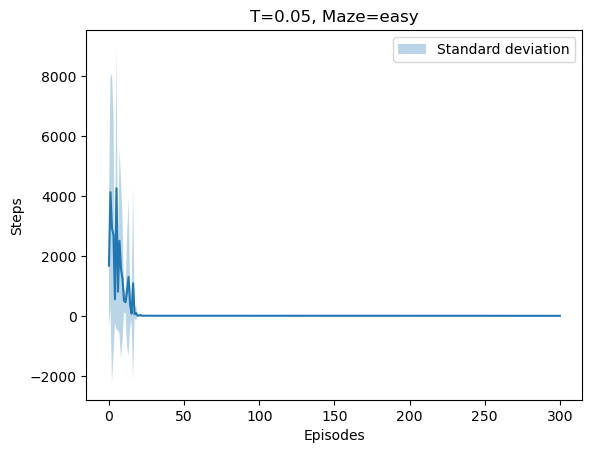

100%|██████████| 300/300 [00:01<00:00, 252.03it/s]


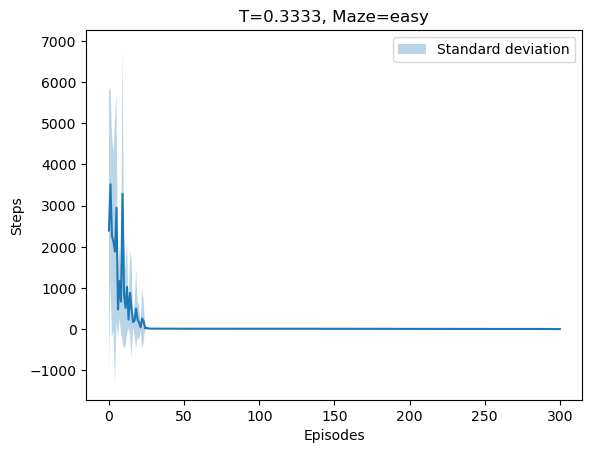

100%|██████████| 300/300 [00:00<00:00, 308.88it/s]


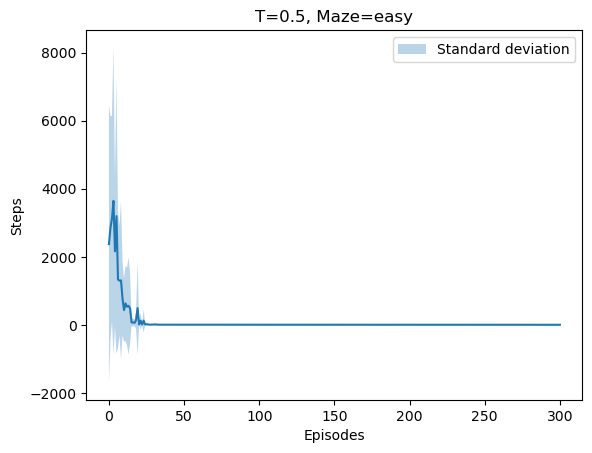

100%|██████████| 300/300 [00:01<00:00, 299.71it/s]


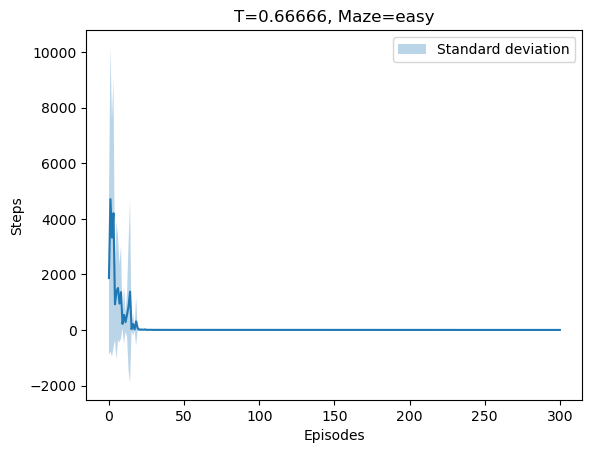

100%|██████████| 300/300 [00:01<00:00, 248.57it/s]


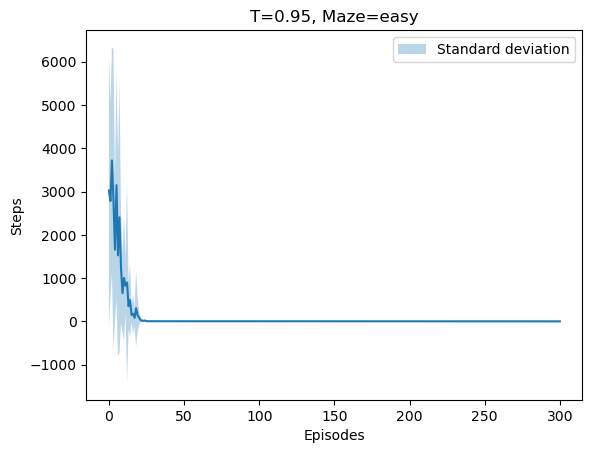

100%|██████████| 300/300 [00:00<00:00, 369.83it/s]


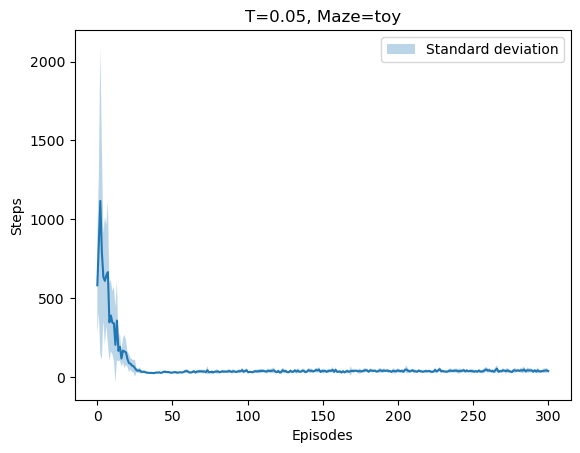

100%|██████████| 300/300 [00:00<00:00, 365.80it/s]


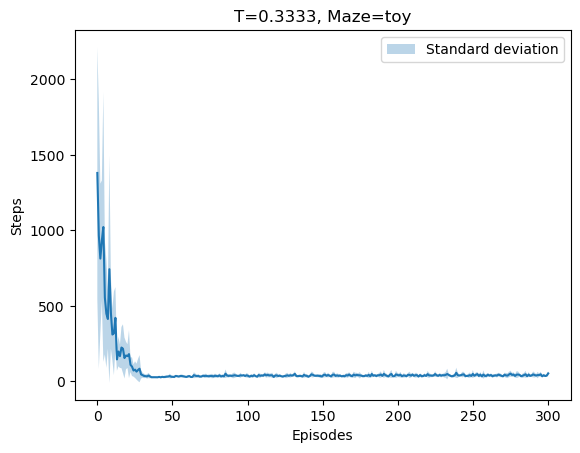

100%|██████████| 300/300 [00:00<00:00, 360.47it/s]


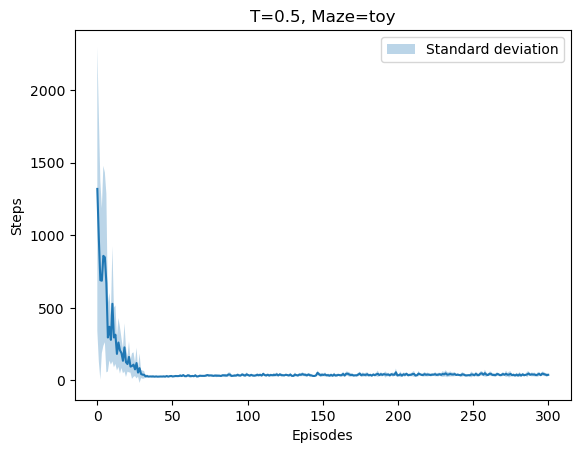

100%|██████████| 300/300 [00:00<00:00, 332.87it/s]


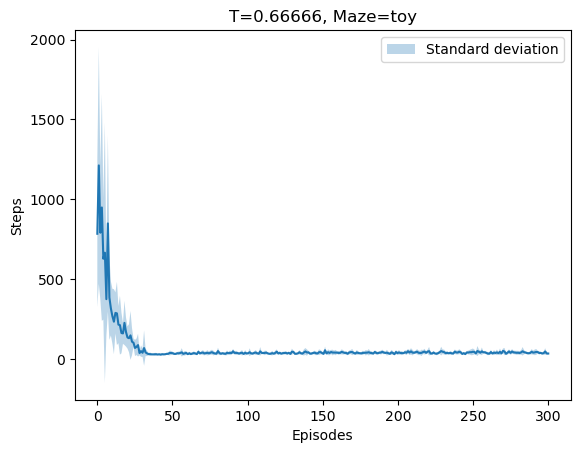

100%|██████████| 300/300 [00:00<00:00, 301.90it/s]


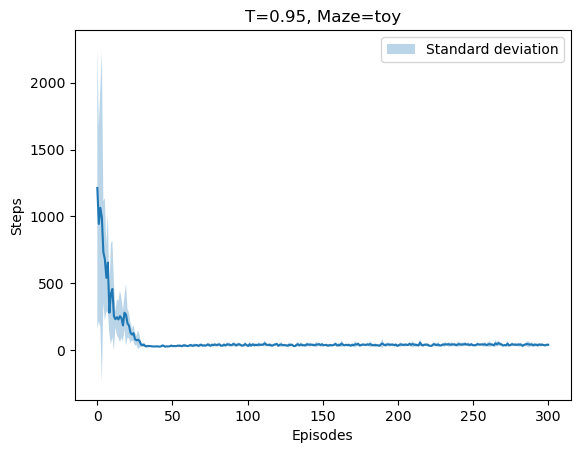

In [55]:
for i in range(len(possMazes)):
    mzString = "./../data/" + possMazes[i] + "_maze.txt"
    curMaze = Maze(file_path=mzString)
    curMaze.set_reward(x=9, y=9, reward=10)
    curMaze.set_terminal(x=9, y=9)
    for k in range(len(possibleVals)):
        runs0 = []
        for j in range(10):
            spc, _, _ = qLearnHPBolt(curMaze, 0.7, 0.9, possibleVals[i])
            runs0.append(spc)
        avg, std = np.mean(runs0, axis=0), np.std(runs0, axis = 0)
        plt.xlabel("Episodes")
        plt.ylabel("Steps")
        plt.title("T=" + str(possibleVals[k]) + ", Maze=" + possMazes[i])
        plt.plot(np.linspace(0, n_episodes, n_episodes), avg)
        plt.fill_between(np.linspace(0, n_episodes, n_episodes), avg - std, avg + std, alpha = 0.3, label = "Standard deviation")
        plt.legend()
        plt.show()

The graphs show that if T is too high or too low convergence will be slow, we can also see that up to T=0.5, the agent seems to converge faster with a higher T, how this stops being the case with T>0.5. The tradeoffs for boltzmann seem to be the same as for e-greedy, that is, a higher T (up to 0.5) will result in faster convergence, however it will also make the agent more unstable.

#### Question 11

In [56]:
def qLearnHPRand(maze, lr, gamma, T):
    agent = Agent(start_x=0, start_y=0)
    # Create a QTable.
    states = maze.get_all_states()
    actions = [Action(id) for id in ["up", "down", "left", "right"]]
    q_table = QTable(states, actions)
    # Create an ExplorationStrategy.
    exploration_strategy = ExplorationStrategy(q_table)
    # Create a learner.
    params = {"lr": lr, "gamma": gamma}
    learner = QLearning(q_table, params)

    # Hyper-parameters.
    n_episodes = 300
    episode_lengths = []
    episode_rewards = []
    steps = np.zeros(n_episodes)
    total_steps = 0
    episodes = 0
    
    for episode in tqdm(range(n_episodes)):
        done = False
        agent.reset()

        while not done and total_steps < 30000:
            state = agent.get_state(maze)
            (next, reward, done), action = exploration_strategy.random(agent, maze)
            valid_actions = agent.get_valid_actions(maze)
            steps[episode] += 1
            total_steps += 1
            if(total_steps >= 30000):
                steps[episode] = 0
            learner.learn(valid_actions, state, action, next, reward, done)
        episodes += 1
    return steps, episodes, total_steps

100%|██████████| 300/300 [00:00<00:00, 766.19it/s]


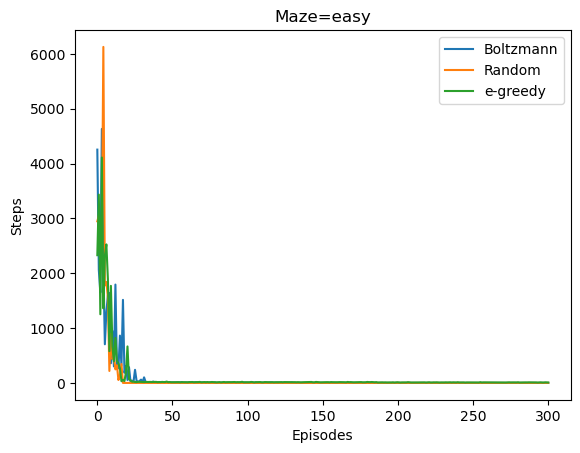

100%|██████████| 300/300 [00:00<00:00, 791.99it/s]


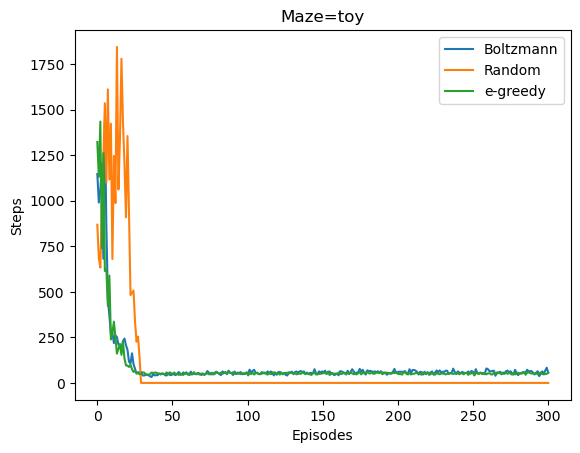

In [60]:
for i in range(len(possMazes)):
    mzString = "./../data/" + possMazes[i] + "_maze.txt"
    curMaze = Maze(file_path=mzString)
    curMaze.set_reward(x=9, y=9, reward=10)
    curMaze.set_terminal(x=9, y=9)
    runs0 = []
    runs1 = []
    runs2 = []
    for j in range(10):
        spc, _, _ = qLearnHPBolt(curMaze, 0.7, 0.9, 0.5)
        runs0.append(spc)
        spc2, _, _ = qLearnHPRand(curMaze, 0.7, 0.9, 0)
        runs1.append(spc2)
        spc3, _, _ = qLearnHP(curMaze, 0.7, 0.9, 0.5)
        runs2.append(spc3)
    avg, std = np.mean(runs0, axis=0), np.std(runs0, axis = 0)
    avg2, std2 = np.mean(runs1, axis=0), np.std(runs1, axis = 0)
    avg3, std3 = np.mean(runs2, axis=0), np.std(runs2, axis = 0)
    plt.xlabel("Episodes")
    plt.ylabel("Steps")
    plt.title("Maze=" + possMazes[i])
    plt.plot(np.linspace(0, n_episodes, n_episodes), avg, label="Boltzmann")
    plt.plot(np.linspace(0, n_episodes, n_episodes), avg2, label="Random")
    plt.plot(np.linspace(0, n_episodes, n_episodes), avg3, label="e-greedy")
    plt.legend()
    plt.show()

We can see from these graphs that the worse, while not apparent in the easy maze, is the random strategy, which performs very poorly on the toy maze. The other 2 seems to perform about the same.

#### Question 12

100%|██████████| 300/300 [00:01<00:00, 251.38it/s]


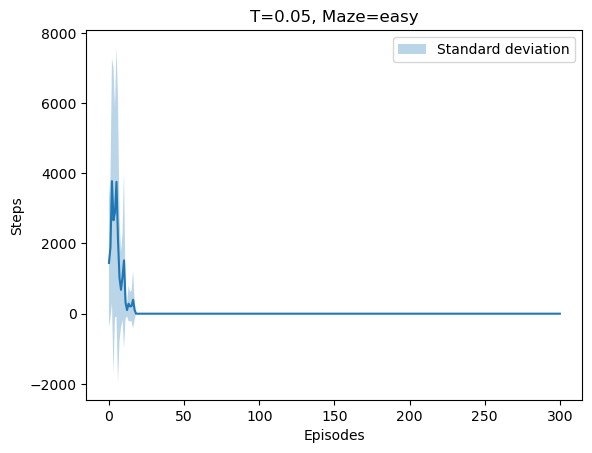

  1%|          | 2/300 [00:00<01:04,  4.64it/s]


KeyboardInterrupt: 

In [ ]:
for i in range(len(possMazes)):
    mzString = "./../data/" + possMazes[i] + "_maze.txt"
    curMaze = Maze(file_path=mzString)
    curMaze.set_reward(x=9, y=9, reward=10)
    curMaze.set_terminal(x=9, y=9)
    for k in range(len(possibleVals)):
        runs0 = []
        for j in range(10):
            spc, _, _ = qLearnHPBolt(curMaze, possibleVals[i], 0.9, 0.5)
            runs0.append(spc)
        avg, std = np.mean(runs0, axis=0), np.std(runs0, axis = 0)
        plt.xlabel("Episodes")
        plt.ylabel("Steps")
        plt.title("Alpha=" + str(possibleVals[k]) + ", Maze=" + possMazes[i])
        plt.plot(np.linspace(0, n_episodes, n_episodes), avg)
        plt.fill_between(np.linspace(0, n_episodes, n_episodes), avg - std, avg + std, alpha = 0.3, label = "Standard deviation")
        plt.legend()
        plt.show()

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

### 2.3 Introducing More Rewards
#### Question 13

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 14

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 15

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

#### Question 16

<div style="background-color:#f1be3e">

_Put your code blocks above (if any) and write your answer here._

## 3. Open Questions
### 3.1 Reflection
#### Question 17

A greedy algorithm will always try the optimal solution available at that point in time, and can thus get stuck in local optima, since it never tries anything different to get a better result.  
We can take the knapsack problem as an example. A greedy solution could pick the best price/weight items, but pick 1 good item that fits the weight limit, while 2 smaller ones that seperately have a worse weight/value score together have a higher one then the one that was picked.  
Example scenario:  
max-cap = 5  
(ID, weight, value) -> items={(A, 1, 6), (B, 2, 10), (C, 3, 12)}.  
This would give us value/weight of (ID, score) -> scores={(A, 6), (B, 5), (C, 4)} 
Based on the scores and weight limits, greedy would pick A & B. For a total value of 16. While picking the less-optimal scores of B & C gives us a value of 22.

#### Question 18

When an agent misunderstands their objective by solely focussing on a reward is when there arise issues. 
If an agent would be in charge of cleaning a room, and getting a reward for how much dust is still detected in the room it might decide that sweeping the dust under the carpet is suffiencent to get their reward, 
and thus not take the extra effort of actually cleaning it up. Simply because it wants the reward, misunderstood that their actions were not actually "reward worthy" when the programmer set that reward for completing the cleaning task



#### Question 19

I don't believe that there is a deterministic solution to this. In the same sense that some humans look for loopholes to get out of their own tasks, or finish their task quickly by ignoring certain (quality based) details. 
Do I also believe that an agent could look for similair shortcuts or loopholes as discussed in the previous question. So a programmer would have to account for any possible loophole and basicall write as many rules as possible to ensure a task is done without shortcuts.

So an evolutionary strategy would be better for solving this "reward issue", see what an agent makes of a task/reward every so often. Punish unwated behavior (Like sweeping dust under the carpet) and give a similair negative reward for actions that are similair to the one it just did (i.e. sweeping the dust under a cupboard instead of the carpet), or give extra rewards for the actually wanted behavior.


### 3.2 Pen and Paper
#### Question 20

Below a graph we made using draw.io


Sadly we coulnd't find an example graph in the lecture slides. So I used to graph found on the MDP wikipedia page as inspiration. 

Explanation of graph elements:

The circles are states labeled as S[0-2][ABE] depending on what the robot is currently carrying. The eliptical shaped objects are descions.

The states include the location that the robot would be in the store. These are simply to make it easier to check the graph, but the actual state names do not include the parentesis, and will thus not be used when refering to a node in further questions.  

Arrows going from a state or action have their probability from a 0-1 scale written in them. An arrow going from a +/-<\INTEGER> are the rewards if they follow that path. These arrows only point to a line, never a state/action.  

For ease of reading did we also include (location) to make it clear. But that is not part of the actual state name that we will be using in further questions

Then the "INVALID_ACTION" action is the set of actions that are not possible from that state. i.e. <\picking berries> in (S0E) would lead you down the INVALID_ACTION path. To avoid an arrow clutter to/from states, these have a bidirectional arrow. Since writing 2 probabilities in these arrows would be confusing, did we intend these to be read as "Take this (set of) action(s) with a probability of 'x' but go back to state it was taken in with probability 1"  

The start state is marked in green, while the terminal state is marked in pink. (S0E and T respectively)

<img src="fin.drawio.png">

#### Question 21

Translating the policy to our graph we get the following actions in each state. Since we have V0 = 0-steps-to-go, the V0 column is full of 0s as there are no points to be gained in 0 steps.
| State name | Action      |V0 |
|------------|-------------|---|
|S0A         |Pick berries | 0 |
|S1A         |Pick berries | 0 | 
|S2A         |Pick berries | 0 |
|S0E         |Pick berries | 0 |
|S1E         |Pick berries | 0 |
|S2E         |Pick berries | 0 |
|S0B1        |Pick berries | 0 |
|S1B1        |Pick 2nd box | 0 |
|S2B1        |Pick berries | 0 |
|S0B2        |Forward      | 0 |
|S1B2        |Forward      | 0 |
|S2B2        |Pay          | 0 |
|T           |<\Episode end\>| 0 |

From this we can already deduce that this policy will never actually reach T, as it is stuck on S0E (Entrance, Empty) since it never moves to the aisle to perform the valid "Pick Berries" action.
So the V1 and V2 calculations only need to take the start state into account

V1 = -1 + 0.9\*0 = -1

V2 = -1 + + 0.9\*-1 = -1.9


#### Question 22

I would have this depend on the times the robot made a mistake. If you are still in S1E but at a score of -5, you would need to get the 2 berries to end up with a positive score. 
Otherwise I would have it be dependend on the expected value of apple and berries. Since the assignment states that we should not be doing any calculations I will not be calculating these expected values.
But at any given point in time, we should attempt to get the highest possible score. While also taking into acount that getting 2 berries keeps us in the episode the longest, and thus give the most opportunity to make mistakes and drop the score.


My intuition tells me, given this strategy, that going for apples and trying to pay directly is the best strategy overall. Since it can be done in 4 descisions at best while still rewarding 5 points.

### 3.3 Division of Work

#### Question 23

|          Component          |   Zeyd    |   Vasco   |   Mats    |   Kylian  |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |    25%    |    25%    |    25%    |    25%    |
| Code (implementation)       |    25%    |    25%    |    25%    |    25%    |
| Code (validation)           |    25%    |    25%    |    25%    |    25%    |
| Experiments (execution)     |    25%    |    25%    |    25%    |    25%    |
| Experiments (analysis)      |    25%    |    25%    |    25%    |    25%    |
| Experiments (visualization) |    25%    |    25%    |    25%    |    25%    |
| Report (original draft)     |    25%    |    25%    |    25%    |    25%    |
| Report (reviewing, editing) |    25%    |    25%    |    25%    |    25%    |

### References

**If you made use of any non-course resources, cite them below.**

https://en.wikipedia.org/wiki/Markov_decision_process